In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : "#f9fbff",
    'axes.facecolor'   : "#ffffff",
    'axes.edgecolor'   : '#2e3148',
    'axes.labelcolor'  : "#000000",
    'text.color'       : "#000000",
    'xtick.color'      : "#191b1d",
    'ytick.color'      : "#121314",
    'grid.color'       : "#ffffff",
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : "#040404",
})

PALETTE = ["#5caf91", "#448d72", "#40866c", "#34705a", "#2d755b", "#1c4838"]
PROC_DIR = '../data/processed'
VIZ_DIR  = '../visuals'
os.makedirs(VIZ_DIR, exist_ok=True)

accounts        = pd.read_csv(f'{PROC_DIR}/accounts_clean.csv',       parse_dates=['signup_date'])
subscriptions   = pd.read_csv(f'{PROC_DIR}/subscriptions_clean.csv',  parse_dates=['start_date','end_date'])
churn_events    = pd.read_csv(f'{PROC_DIR}/churn_events_clean.csv',   parse_dates=['churn_date'])
support_tickets = pd.read_csv(f'{PROC_DIR}/support_tickets_clean.csv',parse_dates=['submitted_at','closed_at'])

print('Data loaded successfully.')
print(f'  Churn events : {len(churn_events):,}')
print(f'  Churned accts: {accounts["churn_flag"].sum():,} / {len(accounts):,}')

Data loaded successfully.
  Churn events : 600
  Churned accts: 110 / 500


In [ ]:
total_accounts   = len(accounts)
churned_accounts = accounts['churn_flag'].sum()
gross_churn_rate = churned_accounts / total_accounts * 100
reactivations    = churn_events['is_reactivation'].sum()
total_refunds    = churn_events['refund_amount_usd'].sum()
avg_refund       = churn_events[churn_events['refund_amount_usd'] > 0]['refund_amount_usd'].mean()

churned_subs  = subscriptions[subscriptions['churn_flag'] == True]
mrr_churned   = churned_subs['mrr_amount'].sum()
total_mrr     = subscriptions[(subscriptions['is_trial'] == False) &
                               (subscriptions['mrr_amount'] > 0)]['mrr_amount'].sum()
mrr_churn_pct = mrr_churned / total_mrr * 100 if total_mrr > 0 else 0

print('='*45)
print('  CHURN KPI SUMMARY')
print('='*45)
print(f'  Total Accounts        : {total_accounts:,}')
print(f'  Churned Accounts      : {churned_accounts:,}')
print(f'  Gross Churn Rate      : {gross_churn_rate:.1f}%')
print(f'  Reactivations         : {reactivations:,}')
print(f'  Total Refunds Issued  : ${total_refunds:,.2f}')
print(f'  Avg Refund (non-zero) : ${avg_refund:,.2f}')
print(f'  MRR Lost to Churn     : ${mrr_churned:,.2f}')
print(f'  MRR Churn Rate        : {mrr_churn_pct:.1f}%')

  CHURN KPI SUMMARY
  Total Accounts        : 500
  Churned Accounts      : 110
  Gross Churn Rate      : 22.0%
  Reactivations         : 61
  Total Refunds Issued  : $8,652.25
  Avg Refund (non-zero) : $60.93
  MRR Lost to Churn     : $1,179,139.00
  MRR Churn Rate        : 10.4%


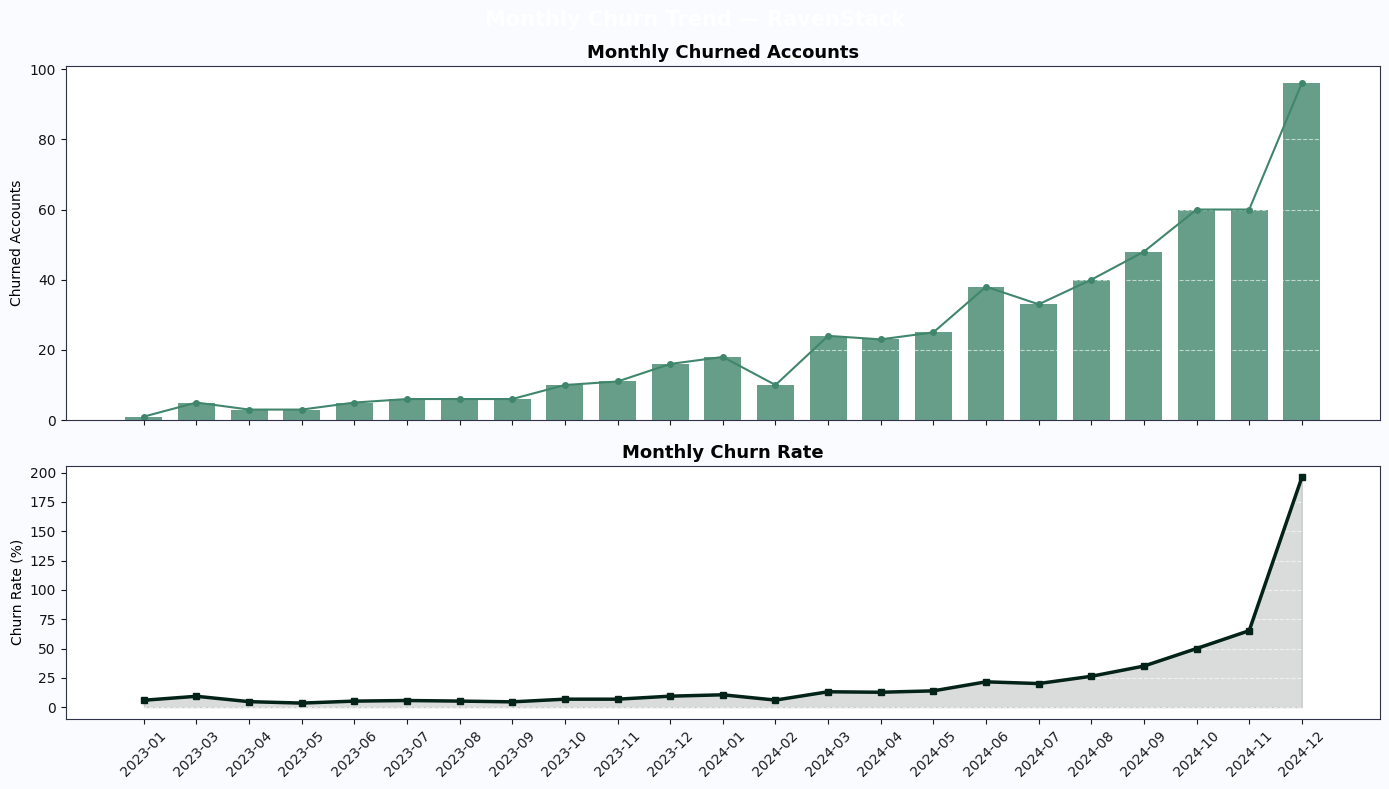

Saved: 10_monthly_churn_trend.png


In [ ]:
churn_events['churn_month'] = churn_events['churn_date'].dt.to_period('M')
monthly_churn = (
    churn_events
    .groupby('churn_month')
    .agg(churned=('account_id', 'nunique'),
         refunds=('refund_amount_usd', 'sum'))
    .reset_index()
)


accounts['signup_month'] = accounts['signup_date'].dt.to_period('M')
monthly_signups = (
    accounts.groupby('signup_month')['account_id']
    .count()
    .rename('new_accounts')
    .reset_index()
    .rename(columns={'signup_month': 'month'})
)
monthly_signups['cumulative'] = monthly_signups['new_accounts'].cumsum()

monthly_churn['month'] = monthly_churn['churn_month']
monthly_merged = monthly_churn.merge(
    monthly_signups[['month', 'cumulative']],
    on='month', how='left'
)
monthly_merged['active_base'] = (
    monthly_merged['cumulative'] - monthly_merged['churned'].shift(1).fillna(0).cumsum()
)
monthly_merged['churn_rate_pct'] = (
    monthly_merged['churned'] / monthly_merged['active_base'].clip(lower=1) * 100
).round(2)

month_str = monthly_merged['month'].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [1.4, 1]})
fig.suptitle('Monthly Churn Trend — RavenStack', fontsize=15,
             fontweight='bold', color="#ffffff")

ax1.bar(month_str, monthly_merged['churned'],
        color=PALETTE[2], alpha=0.80, width=0.7, label='Churned Accounts')
ax1.plot(month_str, monthly_merged['churned'],
          color=PALETTE[2], linewidth=1.5, marker='o', markersize=4)
ax1.set_ylabel('Churned Accounts')
ax1.set_title('Monthly Churned Accounts')
ax1.grid(axis='y')

ax2.plot(month_str, monthly_merged['churn_rate_pct'],
          color="#042318", linewidth=2.5, marker='s', markersize=5)
ax2.fill_between(month_str, monthly_merged['churn_rate_pct'],
                  alpha=0.15, color="#041a11")
ax2.set_ylabel('Churn Rate (%)')
ax2.set_title('Monthly Churn Rate')
ax2.grid(axis='y')
ax2.tick_params(axis='x',labelrotation=45)

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/10_monthly_churn_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 10_monthly_churn_trend.png')

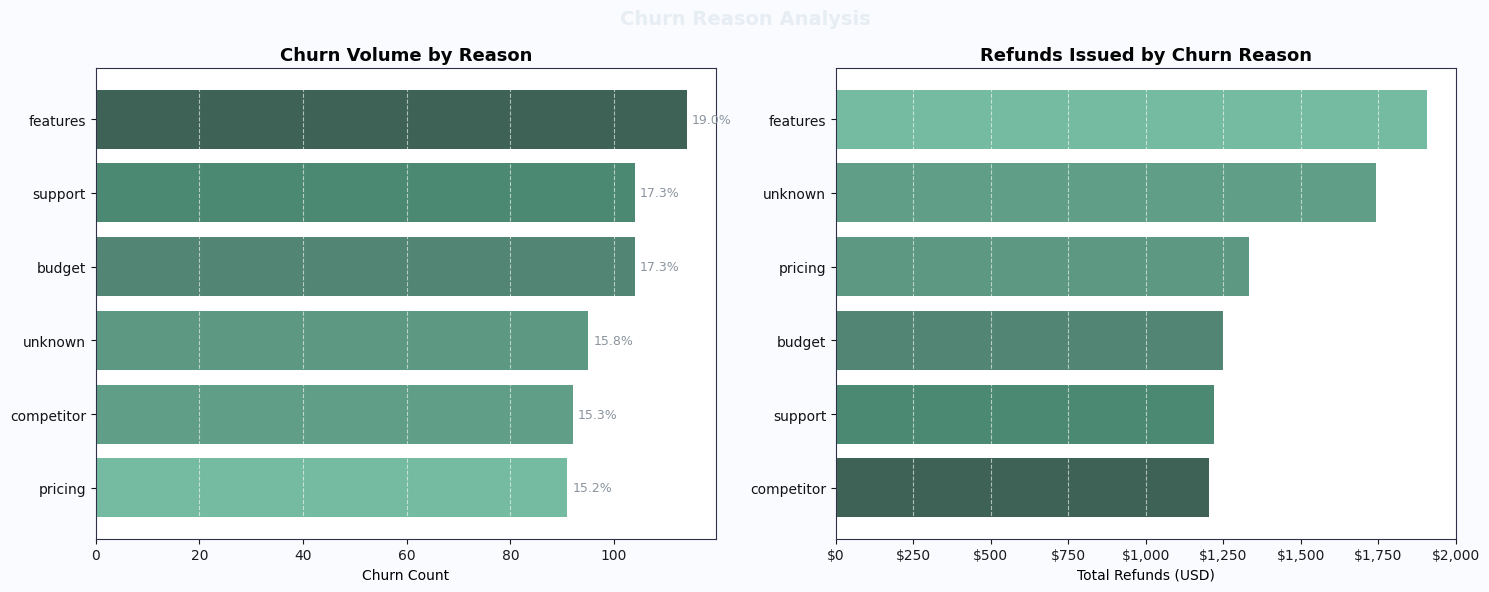

Saved: 11_churn_reasons.png


In [ ]:
reason_summary = (
    churn_events
    .groupby('reason_code')
    .agg(
        count          = ('churn_event_id', 'count'),
        total_refunds  = ('refund_amount_usd', 'sum'),
        reactivations  = ('is_reactivation', 'sum')
    )
    .sort_values('count', ascending=True)
)
reason_summary['pct'] = (reason_summary['count'] /
                          reason_summary['count'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Churn Reason Analysis', fontsize=14, fontweight='bold', color='#e6edf3')

colors = [PALETTE[i % len(PALETTE)] for i in range(len(reason_summary))]
bars = axes[0].barh(reason_summary.index, reason_summary['count'],
                     color=colors, alpha=0.85)
for bar, pct in zip(bars, reason_summary['pct']):
    axes[0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                  f'{pct}%', va='center', fontsize=9, color='#8b949e')
axes[0].set_xlabel('Churn Count')
axes[0].set_title('Churn Volume by Reason')
axes[0].grid(axis='x')

reason_sorted_refunds = reason_summary.sort_values('total_refunds', ascending=True)
axes[1].barh(reason_sorted_refunds.index, reason_sorted_refunds['total_refunds'],
              color=colors[::-1], alpha=0.85)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xlabel('Total Refunds (USD)')
axes[1].set_title('Refunds Issued by Churn Reason')
axes[1].grid(axis='x')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/11_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_churn_reasons.png')

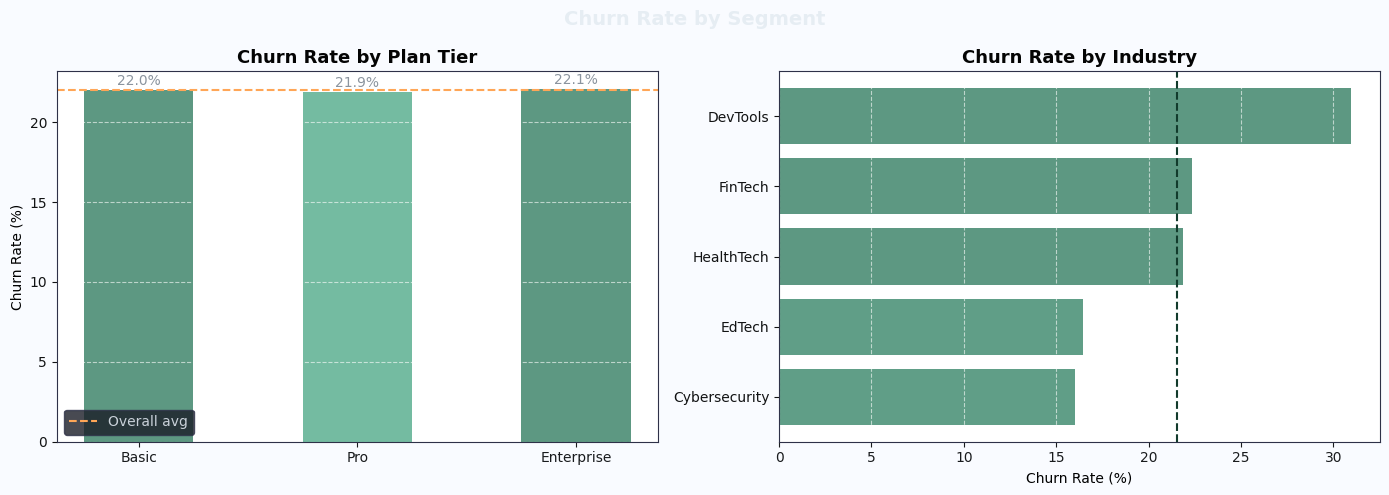

Saved: 12_churn_by_segment.png


In [ ]:
plan_churn = (
    accounts
    .groupby('plan_tier')
    .agg(total=('account_id','count'), churned=('churn_flag','sum'))
    .assign(churn_rate=lambda x: x['churned'] / x['total'] * 100)
)

industry_churn = (
    accounts
    .groupby('industry')
    .agg(total=('account_id','count'), churned=('churn_flag','sum'))
    .assign(churn_rate=lambda x: x['churned'] / x['total'] * 100)
    .sort_values('churn_rate', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Churn Rate by Segment', fontsize=14, fontweight='bold', color='#e6edf3')

plan_order = ['Basic', 'Pro', 'Enterprise']
plan_rates = plan_churn.reindex(plan_order)['churn_rate']
bar_colors = [PALETTE[2] if v > plan_churn['churn_rate'].mean() else PALETTE[0]
               for v in plan_rates]
axes[0].bar(plan_rates.index, plan_rates.values, color=bar_colors, alpha=0.85, width=0.5)
axes[0].axhline(plan_churn['churn_rate'].mean(), color='#ffa657',
                  linestyle='--', linewidth=1.5, label='Overall avg')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Plan Tier')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2e3148', labelcolor='#c9d1d9')
axes[0].grid(axis='y')
for i, v in enumerate(plan_rates.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10, color='#8b949e')

ind_colors = [PALETTE[2] if v > industry_churn['churn_rate'].mean() else PALETTE[1]
               for v in industry_churn['churn_rate']]
axes[1].barh(industry_churn.index, industry_churn['churn_rate'],
              color=ind_colors, alpha=0.85)
axes[1].axvline(industry_churn['churn_rate'].mean(), color='#123b2c',
                  linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Churn Rate (%)')
axes[1].set_title('Churn Rate by Industry')
axes[1].grid(axis='x')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/12_churn_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_churn_by_segment.png')

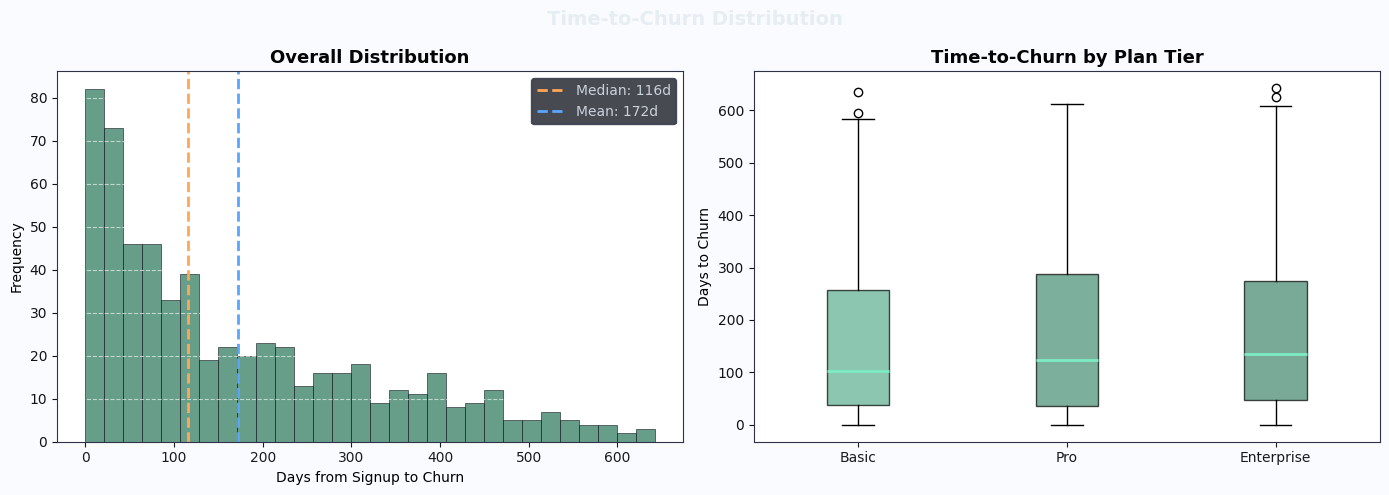

Saved: 13_time_to_churn.png

  Median days to churn : 116
  Mean days to churn   : 172


In [ ]:
ttc = churn_events.merge(
    accounts[['account_id', 'signup_date', 'plan_tier']],
    on='account_id', how='left'
)
ttc['days_to_churn'] = (ttc['churn_date'] - ttc['signup_date']).dt.days
ttc = ttc[ttc['days_to_churn'] >= 0]   # remove artefacts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Time-to-Churn Distribution', fontsize=14, fontweight='bold', color='#e6edf3')


axes[0].hist(ttc['days_to_churn'], bins=30, color=PALETTE[2], alpha=0.80,
              edgecolor='#0f1117', linewidth=0.5)
axes[0].axvline(ttc['days_to_churn'].median(), color='#ffa657',
                  linestyle='--', linewidth=2, label=f'Median: {ttc["days_to_churn"].median():.0f}d')
axes[0].axvline(ttc['days_to_churn'].mean(), color='#58a6ff',
                  linestyle='--', linewidth=2, label=f'Mean: {ttc["days_to_churn"].mean():.0f}d')
axes[0].set_xlabel('Days from Signup to Churn')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Overall Distribution')
axes[0].legend(facecolor='#1a1d27', edgecolor='#2e3148', labelcolor='#c9d1d9')
axes[0].grid(axis='y')


plan_order = ['Basic', 'Pro', 'Enterprise']
plan_data_ttc = [ttc[ttc['plan_tier'] == p]['days_to_churn'].dropna() for p in plan_order]
bp = axes[1].boxplot(plan_data_ttc, labels=plan_order, patch_artist=True,
                      medianprops={'color': "#7becc3", 'linewidth': 2})
for patch, color in zip(bp['boxes'], PALETTE[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Days to Churn')
axes[1].set_title('Time-to-Churn by Plan Tier')
axes[1].grid(axis='y')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/13_time_to_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 13_time_to_churn.png')

print(f'\n  Median days to churn : {ttc["days_to_churn"].median():.0f}')
print(f'  Mean days to churn   : {ttc["days_to_churn"].mean():.0f}')

Avg tickets — Churned  : 3.93
Avg tickets — Retained : 4.02


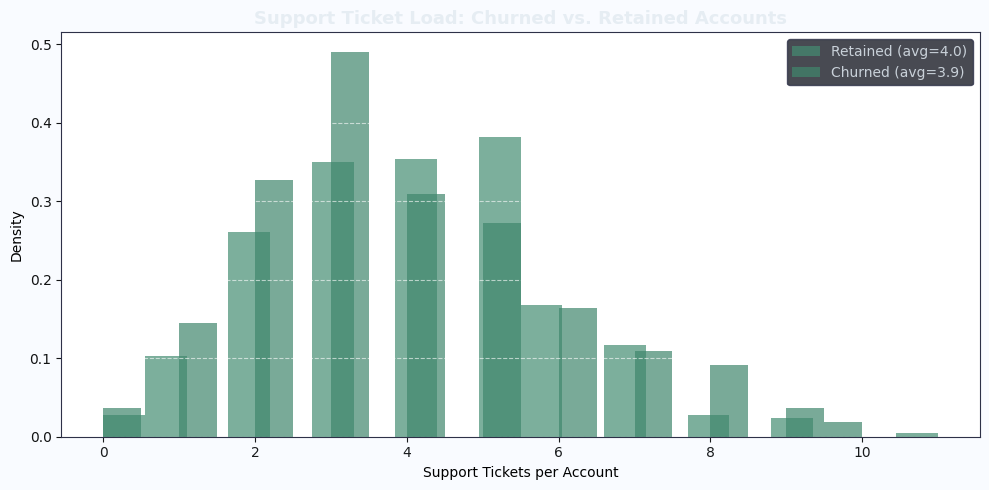

Saved: 14_support_vs_churn.png


In [ ]:
tickets_per_account = (
    support_tickets
    .groupby('account_id')['ticket_id']
    .count()
    .rename('ticket_count')
    .reset_index()
)

signal_df = accounts[['account_id', 'churn_flag', 'plan_tier']].merge(
    tickets_per_account, on='account_id', how='left'
)
signal_df['ticket_count'] = signal_df['ticket_count'].fillna(0)

churned_tickets  = signal_df[signal_df['churn_flag'] == True]['ticket_count']
retained_tickets = signal_df[signal_df['churn_flag'] == False]['ticket_count']

print(f'Avg tickets — Churned  : {churned_tickets.mean():.2f}')
print(f'Avg tickets — Retained : {retained_tickets.mean():.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(retained_tickets, bins=20, alpha=0.70, color=PALETTE[1],
         label=f'Retained (avg={retained_tickets.mean():.1f})', density=True)
ax.hist(churned_tickets,  bins=20, alpha=0.70, color=PALETTE[2],
         label=f'Churned (avg={churned_tickets.mean():.1f})',  density=True)
ax.set_xlabel('Support Tickets per Account')
ax.set_ylabel('Density')
ax.set_title('Support Ticket Load: Churned vs. Retained Accounts',
              fontsize=13, fontweight='bold', color='#e6edf3')
ax.legend(facecolor='#1a1d27', edgecolor='#2e3148', labelcolor='#c9d1d9')
ax.grid(axis='y')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/14_support_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 14_support_vs_churn.png')

In [ ]:
monthly_merged.to_csv(f'{PROC_DIR}/monthly_churn_summary.csv', index=False)
reason_summary.to_csv(f'{PROC_DIR}/churn_reason_summary.csv')
plan_churn.to_csv(f'{PROC_DIR}/churn_by_plan.csv')

print('monthly_churn_summary.csv')
print('churn_reason_summary.csv')
print('churn_by_plan.csv')

downgrade_churn = churn_events['preceding_downgrade_flag'].mean() * 100
upgrade_churn   = churn_events['preceding_upgrade_flag'].mean()   * 100
reactivation_rt = churn_events['is_reactivation'].mean() * 100

print(f'\n=== PRE-CHURN SIGNAL FLAGS ===')
print(f'  Churned after downgrade : {downgrade_churn:.1f}%')
print(f'  Churned after upgrade   : {upgrade_churn:.1f}%')
print(f'  Reactivations           : {reactivation_rt:.1f}% of churn events')

✓ monthly_churn_summary.csv
✓ churn_reason_summary.csv
✓ churn_by_plan.csv

=== PRE-CHURN SIGNAL FLAGS ===
  Churned after downgrade : 8.8%
  Churned after upgrade   : 20.5%
  Reactivations           : 10.2% of churn events
